### Bar Chart for Average Trip Frequency by Household Income:


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#### Load in the data in csv

 # importing the national household travel survey
nhts_data = pd.read_csv('NHTS.csv')

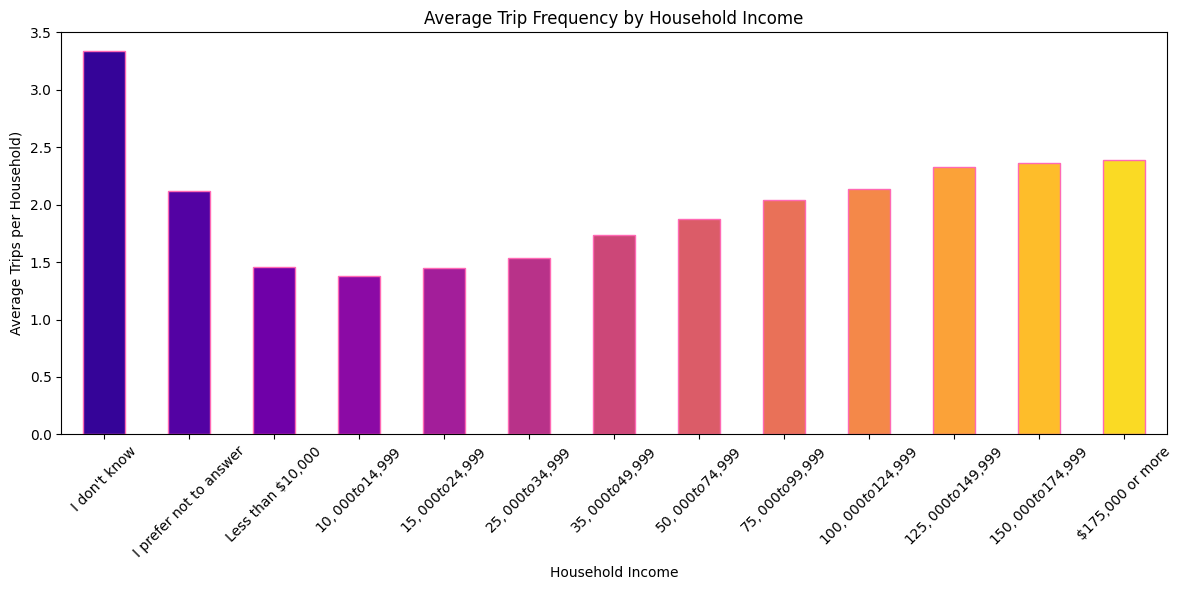

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# This count the trips per household using travel_day
trip_freq = (nhts_data.groupby('household_id')['travel_day'].count().reset_index(name='trip_frequency'))

# This combines trip frequency with household_income
trip_freq = trip_freq.merge(nhts_data[['household_id', 'household_income']].drop_duplicates(), on='household_id',how='left')

# This calculates the average trip frequency per income category
avg_trips = (trip_freq.groupby('household_income')['trip_frequency'].mean().dropna())
income_order = [
    "I don't know",
    'I prefer not to answer',
    'Less than $10,000',
    '$10,000 to $14,999',
    '$15,000 to $24,999',
    '$25,000 to $34,999',
    '$35,000 to $49,999',
    '$50,000 to $74,999',
    '$75,000 to $99,999',
    '$100,000 to $124,999',
    '$125,000 to $149,999',
    '$150,000 to $174,999',
    '$175,000 or more'
]

avg_trips = avg_trips.reindex(income_order)

# This plots the bar graph
plt.figure(figsize=(12,6))

avg_trips.plot(kind='bar', color=sns.color_palette('plasma', len(avg_trips)), edgecolor='hotpink')

plt.xlabel('Household Income')
plt.ylabel('Average Trips per Household)')
plt.title('Average Trip Frequency by Household Income')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()